In [146]:
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv
import operator
import os
load_dotenv()
from langchain_groq import ChatGroq
groq_api_key = os.getenv("GROQ_API_KEY")

In [147]:
class Task(BaseModel):
    id:int = Field(description="The unique identifier for the task")
    title:str = Field(description="The title of the task")
    
    goal:str = Field(...,description="One sentence describing what the reader shoudl be able t  do/understand after completing this section")
    bullets:list[str]=Field(
        ..., 
        min_length=3,
        max_length=5,
        description="3-5 concrete, non-overlapping subpoints to cover in thi section. These should be specific and actionable, not vague or high-level.")
    
    target_words:int = Field(...,description="The target word count for this section (120-450).")
    section_type:Literal["Intorduction","core","examples","checklist","common_mistake","conclusion"] = Field(...,description="Use 'common_mistake' exactly once in the plan.")



In [148]:
class Plan(BaseModel):
    blog_title:str = Field(description="The title of the blog post to be written")
    audience:str = Field(description="The target audience for the blog post")
    tone:str = Field(description="The tone of the blog post")
    tasks:list[Task] = Field(description="A list of tasks to be completed")

In [149]:
class State(TypedDict):
    topic:str = Field(description="The topic to be covered in the plan")
    plan:Annotated[Plan,Field(description="The plan to be executed")]
    sections:Annotated[list[str],operator.add]
    final_blog:str = Field(description="The final blog post that has been written")


In [150]:
llm1 = ChatGroq(
    model="llama-3.1-8b-instant",   # equivalent to Llama 3
    temperature=0.1,
    groq_api_key=groq_api_key
)

llm2 = ChatGroq(
    model="openai/gpt-oss-120b",  # alternative to MiniMax
    temperature=0.1,
    groq_api_key=groq_api_key
)

llm3 = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",   # smaller substitute (Groq doesn't host 1B)
    temperature=0.1,
    groq_api_key=groq_api_key
)

LamaInstant=llm1
OpenAIOSS=llm2
LammaInstruct=llm3

In [151]:
import pprint
def planner(state: State) -> dict:
    plan = OpenAIOSS.with_structured_output(Plan).invoke([
       SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
    ])
    # pprint.pprint("Generated Plan:" + str(plan))
    return {"plan": plan}

In [152]:
from langgraph.types import Send

def fanout(state: State):
    tasks = state["plan"].tasks

    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"]
            }
        )
        for task in tasks
    ]
# The worker function is responsible for taking each task from the plan and generating the corresponding section of the blog post. 
# This executed workers parallely for each task in the plan.

In [153]:
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    
    bullets_text = "\n- " + "\n- ".join(task.bullets)
   
    section_content = LammaInstruct.invoke(
        [
            SystemMessage(
                content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()
    return {"sections": [section_content]}

In [154]:
import re
from pathlib import Path
def reducer(state:State)->dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_blog = f"# {title}\n\n{body}\n"

   # 2. Sanitize the filename (Remove colons, commas, etc.)
    # This replaces any character that isn't alphanumeric, space, or underscore
    clean_title = re.sub(r'[^\w\s-]', '', title).strip().lower()
    filename = clean_title.replace(" ", "_") + ".md"
    
    output_path = Path(filename)
    
    try:
        output_path.write_text(final_blog, encoding="utf-8")
        print(f"Successfully saved to: {filename}")
    except Exception as e:
        print(f"Error saving file: {e}")

    return {"final_blog": final_blog}

In [155]:
graph=StateGraph(State)
graph.add_node("planner",planner)
graph.add_node("worker",worker)
graph.add_node("reducer",reducer)

graph.add_edge(START,"planner")
graph.add_conditional_edges("planner",fanout,["worker"])
graph.add_edge("worker","reducer")
graph.add_edge("reducer",END)

workflow=graph.compile()

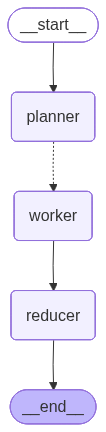

In [156]:
workflow

In [157]:
response=workflow.invoke({"topic":"Write a Blog on Global Recession"})
pprint.pprint(response)

Successfully saved to: building_a_datadriven_global_recession_forecasting_pipeline.md
{'final_blog': '# Building a Data‑Driven Global Recession Forecasting '
               'Pipeline\n'
               '\n'
               '## Introduction – Why Forecast a Global Recession?\n'
               '\n'
               'A global recession is a synchronized downturn in economic '
               'activity across multiple countries, typically defined by a '
               'decline in global GDP, increased unemployment, and reduced '
               'economic output. Early detection of a recession is crucial for '
               'businesses, governments, and investors to adjust product '
               'roadmaps, manage risk, and make informed decisions. A reliable '
               'forecast enables proactive measures to mitigate potential '
               'losses and capitalize on opportunities.\n'
               '\n'
               'The current state of recession modeling is dominated by '
        